<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/07_01_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# MBC 마켓이 럭키백 이벤트를 패션 분야에 접목시키고자 한다.

# 딥러닝의 시작, 인공 신경망

# MNIST 데이터 셋 : 손으로 작성한 0부터 9까지의 숫자로 이루어져 있다.
# 패션 MNIST 데이터 셋 : 숫자 대신 패션 아이템으로 이루어져 있다.
# https://www.kaggle.com/datasets : 캐글의 연습용 데이터 셋
# https://www.aihub.or.kr/ : 국내에서 제공하는 연습용 데이터 셋 & 동영상 강의

# 텐서플로 연산을 만든다.
# pip install tensorflow (in PyCharm)
import tensorflow as tf # 텐서플로

tf.keras.utils.set_random_seed(42) # 실행마다 동일한 결과를 얻기 위해, 케라스에 랜덤 시드를 사용한다.
tf.config.experimental.enable_op_determinism() # 파이참과 같은 다른 프로그램에서의 버전 오류를 해결한다.
from tensorflow import keras # 케라스 패키지를 불러온다.

(train_input, train_target), (
    test_input, test_target) = keras.datasets.fashion_mnist.load_data()
# input과 target의 쌍으로 이루어진다.
# load_data : 데이터를 훈련 세트와 테스트 세트로 나누어 반환한다.

In [4]:
print(train_input.shape, train_target.shape) # 전달받은 데이터의 크기를 확인한다.

# 결과 : 트레이닝 세트 (개수, 가로, 세로), 타깃 (개수, (1차원 배열))

(60000, 28, 28) (60000,)


In [5]:
print(test_input.shape, test_target.shape)

# 결과 : 테스트 세트 (개수, 가로, 세로), 타깃 (개수, (1차원 배열))

(10000, 28, 28) (10000,)


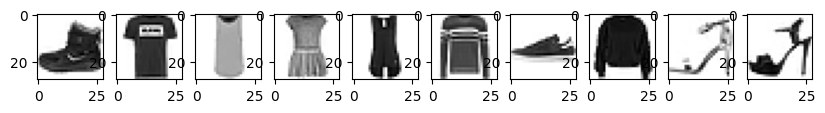

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize = (10, 10))
for i in range(10) :
  axs[i].imshow(train_input[i], cmap = 'gray_r')
  axs[i].axis('on')
plt.show()

# 결과 : 0 → 티셔츠 | 1 → 바지 | 2 → 스웨터 | 3 → 드레스 | 4 → 코트 | 5 → 샌달 | 6 → 셔츠 | 7 → 스니커즈 | 8 → 가방 | 9 → 앵클부츠

In [8]:
print([train_target[i] for i in range(10)]) # 샘플 타깃을 확인한다.

# 결과 : 0부터 9까지의 타깃이 있다.

[np.uint8(9), np.uint8(0), np.uint8(0), np.uint8(3), np.uint8(0), np.uint8(2), np.uint8(7), np.uint8(2), np.uint8(5), np.uint8(5)]


In [9]:
import numpy as np

print(np.unique(train_target, return_counts=True))

# 결과 : 10개 배열에 600개씩 샘플이 들어있다.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


In [10]:
# 로지스틱 회귀를 활용하여 패션 아이템을 분류해보자.

# 확률적 경사 하강법 : SGDClassifier (분류용) → 표준화 전처리된 데이터를 사용한다.
# 패션 MNIST의 경우, 흑백이기 때문에 0부터 255까지의 정수 값을 가진다. → 양수로 이루어진 이미지를 전처리를 하기 위해, 255로 나눈 후 0 ~ 1 사잇값으로 정규화를 진행한다.

# 'reshape'로 2차원 배열을 1차원 배열로 펼친다.
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28 * 28) # -1 : 모든 값
print(train_scaled.shape)

(60000, 784)


In [11]:
from sklearn.model_selection import cross_validate # 크로스 검증
from sklearn.linear_model import SGDClassifier # 경사 하강법

sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42) # max_iter=n : 반복 횟수
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score'])) # 5번 반복에 대한 테스트 평균을 출력한다.

# 결과 : 35초 정도 걸린다.

0.8194166666666666


In [ ]:
# 로지스틱 회귀 : z = a * (Weight) + b * (Length) + c * (Diagonal) + d * (Height) + e * (Width) + f

# 선형 방정식 : z_티셔츠 = a * (픽셀1) + b * (픽셀2) + c * (픽셀3) + d * (픽셀4) ... + e * (픽셀784) + f (절편)

# 바지에 대한 출력 (티셔츠와 다른 값을 사용해야 한다.) : z_바지 = a1 * (픽셀1) + b1 * (픽셀2) + c1 * (픽셀3) + d1 * (픽셀4) ... + e1 * (픽셀784) + f1 (절편)

# 나머지 클래스에 대한 선형 방정식도 동일하다. → 10개의 클래스에 대한 선형 방정식을 모두 계산한다.
# 다음 단계인 '소프트맥스 함수'를 통과하여 각 클래스에 대한 확률을 얻는다.

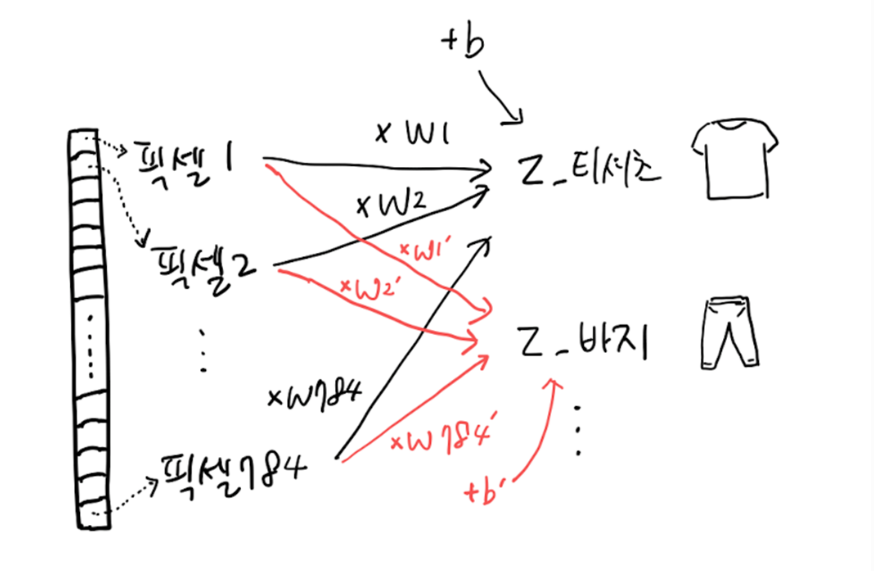

In [ ]:
# 인공 신경망(Artificial Neural Network)
# 출력층(Output Layer) : 신경망의 최종 값
# 입력층(Input Layer) : 픽셀 1번부터 784번까지 → train_scaled
# 뉴런(Neuron) : 인공 신경망의 'z'값을 계산하는 단위 → 선형 계산 (대부분 유닛이라고 부른다.)

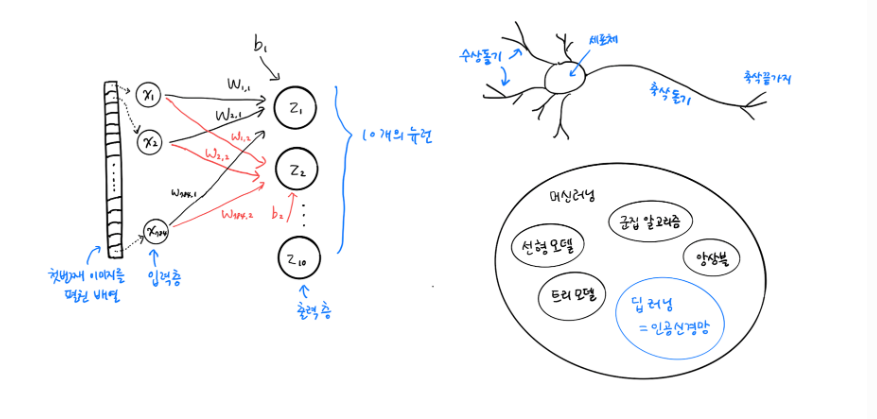

In [ ]:
# 딥러닝 라이브러리에서 인기가 높은 텐서플로를 사용해보자.

# 텐서플로(TensorFlow) : 구글이 2015년 11월 오픈소스로 공개한 딥러닝 라이브러리

import tensorflow as tf

from tensorflow import keras # keras(케라스) : 고수준 api

# 딥러닝 라이브러리는 GPU(그래픽 카드)를 사용하여 인공 신경망을 훈련한다. → 곱셈과 덧셈이 많이 수행되는 인공 신경망의 속도를 높여 준다.
# 단, 케라스 라이브러리는 직접 GPU 연산을 수행하지 않는다. → GPU 연산을 수행하는 다른 라이브러리를 백엔드로 사용한다. (텐서플로 → 멀티 - 백엔드 케라스)
# 케라스 API만 익히면, 다양한 딥러닝 라이브러리를 적시 적소에 사용할 수 있다.
# https://www.youtube.com/watch?v=AKob3yZT0I4


In [12]:
# 인공 신경망으로 모델을 생성할 때 'train_scaled', 'train_target'을 사용한다. → 교차 검증을 사용하지 않고, 검증 세트를 통해 별도로 덜어내어 사용한다.
# 이유 1 : 딥러닝 분야의 데이터 셋은 충분히 크기 때문에 검증 점수가 안정적이다.
# 이유 2 : 교차 검증을 수행하기에는 훈련시간이 너무 오래 걸린다.

from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)
# val_scaled : 값 스케일 == 검증 세트 中 20%
# val_target : 값 타깃 == 검증 세트 中 20%

print(train_scaled.shape, train_target.shape) # 훈련 세트
print(val_scaled.shape, val_target.shape) # 검증 세트

# 결과 : 훈련 세트 48,000 + 검증 세트 12,000 = 60,000

(48000, 784) (48000,)
(12000, 784) (12000,)


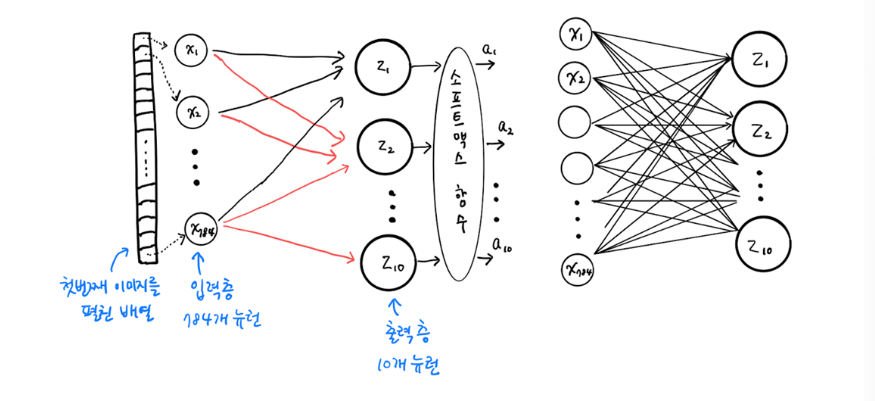

In [ ]:
# 딥러닝에서는 다양한 종류의 층을 추가하는 방식으로 모델을 생성한다.
# 이번 장에서는 'Dense(밀집층, 완전 연결층)'층을 사용하고자 한다.

# 밀집층(Dense Layer) : 가장 기본이 되는 층으로서, 784개의 픽셀과 10개의 뉴런이 모두 연결된 선이다.
# 뉴런이 모두 연결하고 있기 때문에 완전 연결층(fully connected layer)라고도 부른다.

# 10개의 유닛 → 10개의 타깃
# 활성화 함수 (뉴런의 선형 방정식의 계산 결과에 적용되는 함수) : 소프트맥스 함수 (다중 분류)
# 입력 값 : 784개의 원소로 이루어진 1차원 배열 (픽셀 : 28 * 28)
# 케라스 모델 : 첫 번째 층에 입력 크기를 입력한다. (그 다음 층부터는 자동으로 계산되기 때문에 입력할 필요 없다.) → 순차적(Sequential) 클래스
# 인공 신경망의 오른쪽에 놓인 층을 만든다. → 10개의 패션 아이템을 분류하기 위해서 10개의 뉴런으로 구성한다.

In [14]:
# ------------------------------------------------------------------------------
#                       케라스 모델 훈련 전 설정 단계
# ------------------------------------------------------------------------------

# 딥러닝에서 사용할 레이어를 만든다.

dense = keras.layers.Dense(10,       activation='softmax', input_shape=(784,))
#                       뉴런 개수     뉴런에 적용할 함수     입력의 크기
# activation='softmax' : 출력되는 값을 확률로 바꾼다. (다중 분류)
# 입력 크기의 경우, 10개의 뉴런이 각각 몇 개의 입력을 받는지 튜플로 지정한다.

In [15]:
# 밀집층을 가진 신경망 모델을 생성하자.

model = keras.Sequential([dense])
# Sequential(순차적 구조) 클래스를 사용한다. → 앞서 만든 밀집층의 객체 'dense'를 전달한다.
# model 객체 == 신경망 모델

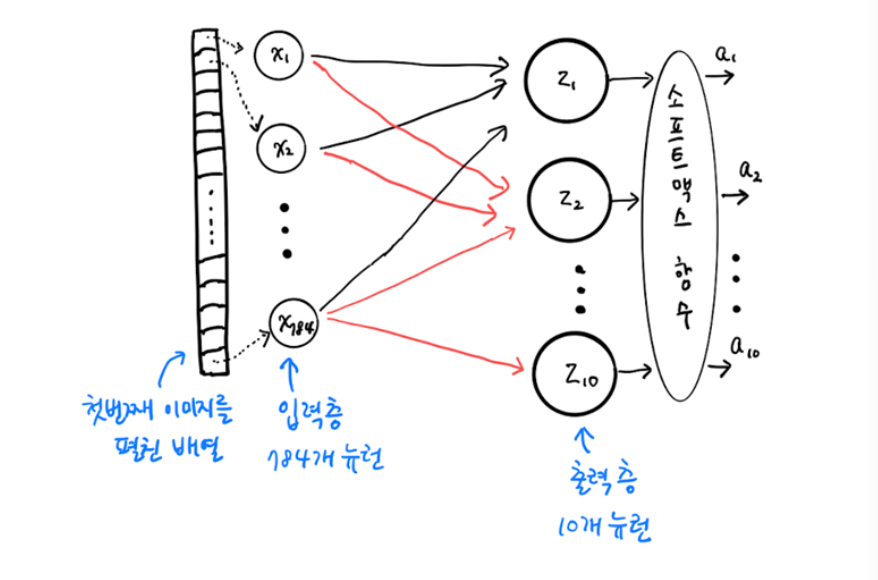

In [16]:
# ------------------------------------------------------------------------------
#                                  모델 컴파일
# ------------------------------------------------------------------------------

# 손실 함수 loss='sparse_categorical_crossentropy' : 정수 타깃 (히소 다중 분류 손실 함수)
#                'sparse_binary_crossentropy' : 이진 타깃 (히소 이진 분류 손실 함수)
# 측정 값 : metrics=['accuracy'] → 정확도의 지표가 된다.

model.compile(loss ='sparse_categorical_crossentropy', metrics=['accuracy'])

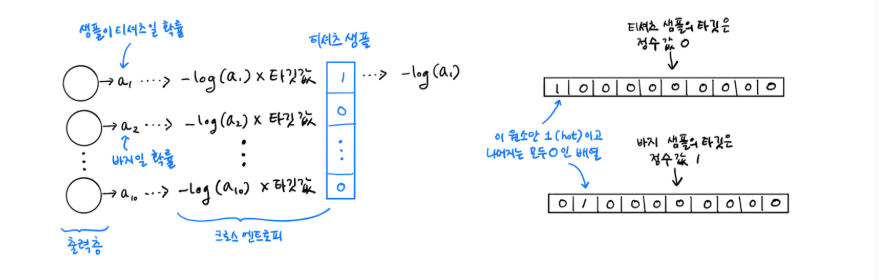

In [19]:
print(train_target[:10]) # 정수형으로 타깃이 생성되어 있다. → 원 - 핫 인코딩

# 결과 : 정답에 인덱스가 출력된다.

[7 3 5 8 6 9 3 3 9 9]


In [21]:
# ------------------------------------------------------------------------------
#                                  모델 훈련
# ------------------------------------------------------------------------------

model.fit(train_scaled, train_target, epochs=5)

# 결과 : 약 25초 정도 걸린다.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7354 - loss: 0.7875
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8336 - loss: 0.4851
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8450 - loss: 0.4564
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8507 - loss: 0.4422
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8534 - loss: 0.4335


In [22]:
# ------------------------------------------------------------------------------
#                                  모델 평가
# ------------------------------------------------------------------------------

model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8456 - loss: 0.4358


[0.4437466263771057, 0.8464999794960022]

In [ ]:
# 사이킷런 모델 vs 케라스 모델 (이미지 참고)

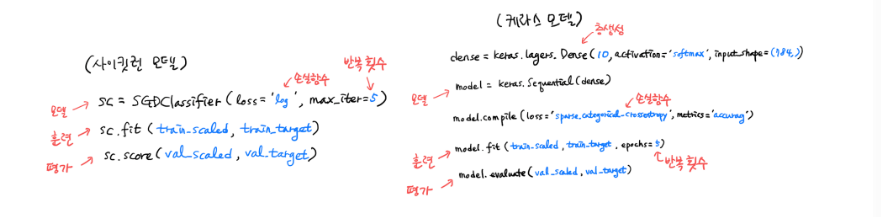